In [1]:
import os
os.environ["MY_NUMBA_TARGET"] = "cuda"

from complex_langevin.compiler.factory import get_backend
backend = get_backend()

import numpy as np


/home/fabianhelmberger/miniconda3/envs/cl_gpu/lib/python3.10/site-packages/llvmlite/binding/ffi.py:175: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Using CUDA backend.


In [2]:
import math
@backend.kernel
def kernel_function(i, arr, val1, val2, val3, coeffs):
    x = val1[i]
    y = val2[i]
    z = val3[i]

    # Compute a heavy polynomial with mixed ops
    acc = 0.0
    for j in range(10):
        a = x + coeffs[j % 4] * y - z
        b = math.sin(a) + math.cos(a) * math.exp(-abs(a))
        c = math.sqrt(abs(b) + 1e-6)
        d = math.log1p(c + 1e-2)

        if j % 2 == 0:
            acc += d**2 - math.tanh(c)
        else:
            acc += d * c + a * b

    acc += x**4 / 4 + x**3 / 3 + x**2 / 2 + x
    arr[i] = acc

In [ ]:
import os
os.environ["MY_NUMBA_TARGET"] = "cuda"

from complex_langevin.compiler.factory import get_backend
backend = get_backend()

import numpy as np
from numba import cuda

num = int(1e2)
arr = np.zeros(num, dtype=np.int32)
d_arr = cuda.to_device(arr)

@backend.kernel
def kernel(i, arr):
    arr[i] = i * i

backend.parallel_loop(kernel, num, d_arr)
expected = np.array([i * i for i in range(num)], dtype=np.int32)
arr = d_arr.copy_to_host()


Using CUDA backend.


/home/fabianhelmberger/miniconda3/envs/cl_gpu/lib/python3.10/site-packages/numba/cuda/compiler.py:726: NumbaPerformanceWarning: Grid size (1) < 2 * SM count (6) will likely result in GPU under utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


array([   0,    1,    4,    9,   16,   25,   36,   49,   64,   81,  100,
        121,  144,  169,  196,  225,  256,  289,  324,  361,  400,  441,
        484,  529,  576,  625,  676,  729,  784,  841,  900,  961, 1024,
       1089, 1156, 1225, 1296, 1369, 1444, 1521, 1600, 1681, 1764, 1849,
       1936, 2025, 2116, 2209, 2304, 2401, 2500, 2601, 2704, 2809, 2916,
       3025, 3136, 3249, 3364, 3481, 3600, 3721, 3844, 3969, 4096, 4225,
       4356, 4489, 4624, 4761, 4900, 5041, 5184, 5329, 5476, 5625, 5776,
       5929, 6084, 6241, 6400, 6561, 6724, 6889, 7056, 7225, 7396, 7569,
       7744, 7921, 8100, 8281, 8464, 8649, 8836, 9025, 9216, 9409, 9604,
       9801], dtype=int32)

Using CUDA backend.


/home/fabianhelmberger/miniconda3/envs/cl_gpu/lib/python3.10/site-packages/numba/cuda/compiler.py:726: NumbaPerformanceWarning: Grid size (1) < 2 * SM count (6) will likely result in GPU under utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/fabianhelmberger/miniconda3/envs/cl_gpu/lib/python3.10/site-packages/numba/cuda/compiler.py:726: NumbaPerformanceWarning: Grid size (1) < 2 * SM count (6) will likely result in GPU under utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/fabianhelmberger/miniconda3/envs/cl_gpu/lib/python3.10/site-packages/numba/cuda/compiler.py:726: NumbaPerformanceWarning: Grid size (2) < 2 * SM count (6) will likely result in GPU under utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/fabianhelmberger/miniconda3/envs/cl_gpu/lib/python3.10/site-packages/numba/cuda/compiler.py:726: NumbaPerformanceWarning: Grid size (4) < 2 * SM count (6) will likely result in GPU under utilization due

Using NUMBA backend.


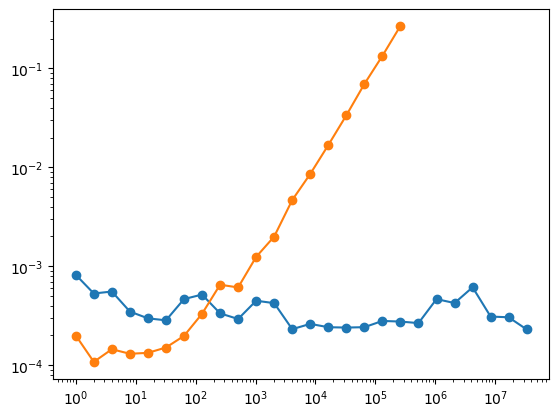

In [3]:


import time
from numba import cuda

import os
os.environ["MY_NUMBA_TARGET"] = "cuda"

from complex_langevin.compiler.factory import get_backend
backend = get_backend()

times_cuda = []
for num in range(int(np.log2(10**8))):
    num = int(2**num)
    arr= np.zeros(num)
    val1 = np.ones(num)
    val2= np.ones(num)
    val3 = np.ones(num)
    coeff = np.ones(num)

    d_arr = cuda.to_device(arr) if os.environ["MY_NUMBA_TARGET"] == "cuda" else arr
    d_val1 = cuda.to_device(val1) if os.environ["MY_NUMBA_TARGET"] == "cuda" else val1
    d_val2 = cuda.to_device(val2) if os.environ["MY_NUMBA_TARGET"] == "cuda" else val2
    d_val3 = cuda.to_device(val3) if os.environ["MY_NUMBA_TARGET"] == "cuda" else val3
    d_coeff = cuda.to_device(coeff) if os.environ["MY_NUMBA_TARGET"] == "cuda" else coeff

    backend.parallel_loop(kernel_function, num, d_arr, d_val1, d_val2, d_val3, d_coeff)
    start = time.time()
    backend.parallel_loop(kernel_function, num, d_arr, d_val1, d_val2, d_val3, d_coeff)
    end = time.time()
    times_cuda.append(end - start)

import os
os.environ["MY_NUMBA_TARGET"] = "numba"

from complex_langevin.compiler.factory import get_backend
backend = get_backend()
times_numba = []

for num in range(int(np.log2(10**6))):
    num = int(2**num)
    arr= np.zeros(num)
    val1 = np.ones(num)
    val2= np.ones(num)
    val3 = np.ones(num)
    coeff = np.ones(num)

    backend.parallel_loop(kernel_function, num, arr, val1, val2, val3, coeff)
    start = time.time()
    backend.parallel_loop(kernel_function, num, arr, val1, val2, val3, coeff)
    end = time.time()
    times_numba.append(end - start)

import matplotlib.pyplot as plt
plt.plot([2**i for i in range(len(times_cuda))], times_cuda, marker='o')
plt.plot([2**i for i in range(len(times_numba))], times_numba, marker='o')
plt.xscale('log')
plt.yscale('log')